In [ ]:
using IonSim
using QuantumOptics
using PyPlot

In [2]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


plot_wigner (generic function with 1 method)

In [3]:
function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

   k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1/4.
# geometric_factor = 1.0 / 4.0
geometric_factor = 1.0 / ( sqrt(3)) 

# STRETCHED STATE: The CG coefficient is exactly 1.0! 
cg_factor = 1.0 # The Clebsch-Gordan factor for Δm=0 in Ca40

# The true effective Rabi frequency acting on the ion's orbitals
Omega_eff = laser_intensity * geometric_factor * cg_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * tspan_end 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end


SDF_apply_with_alpha (generic function with 5 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Simulating bichromatic displacement...
--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 577350.2691896259 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.718
-----------------------------------------
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.5477213734090359 - 0.00023487500897333im
  -0.5476007566119574 + 0.00023485529864395im
  0.00016780822031409 + 0.39163878669608054im
  -0.0001678462875938 - 0.39163884881932054im
 -0.19772909785026843 + 8.469671539906e-5im
  0.19785594232118597 - 8.47091739709e-5im
   -3.490070021561e-5 - 0.0814617953903451im
     3.48303344135e-5 + 0.08146158848660194im
  0.02899792282099058 - 1.241159389896e-5im
 -0.02904140963773813 + 1.241755491722e-5im
     3.96490666221e-

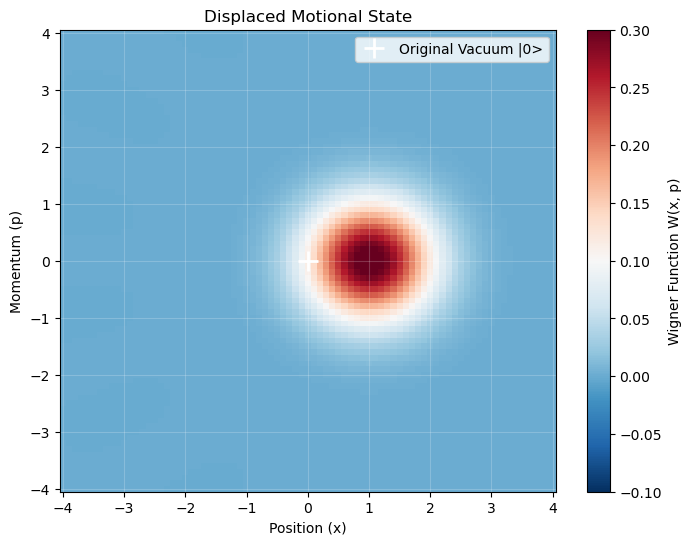

In [4]:
final_state = SDF_apply_with_alpha(0, 50.0, false)

println(final_state)
plot_wigner(final_state)



In [5]:
trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)
    mode = zmodes(trap)[1]
    println(mode)
    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    # 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.716 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
     0.54722151763696 + 0.0im
    -0.54722151763696 + 0.0im
                  0.0 + 0.39181060662806294im
                  0.0 - 0.39181060662806294im
 -0.19836918681147203 + 0.0im
  0.19836918681147203 + 0.0im
                  0.0 - 0.08200240843749869im
                  0.0 + 0.08200240843749869im
  0.02935686222252916 + 0.0im
 -0.02935686222252916 + 0.0im
                  0.0 + 0.0094002121203422im
                  0.0 - 0.0094002121203422im
 -0.00274773650091092 + 0.0im
  0.00274773650091092 + 0.0im
                  0.0 - 0.00074359780052438im
                  0.0 + 0.00074359780052438im
  0.00018824989148011 + 0.0im
 -0.00018824989148011 + 0.0im
                  0.0 + 4.484896272068e-5im
                  0.0 - 4.484896272068e-5im
   -1.061027626674e-5 + 0.0im
    1.061027626674e-5 + 0.0im


In [48]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]
    
    return final_state
end

SDF_apply_with_alpha (generic function with 6 methods)

In [34]:
function protocol(initialstate = nothing, beta = 1, alpha = 0.5)

    beta_state = SDF_apply_with_alpha(0, beta, false, initialstate, 0)
    final_state = SDF_apply_with_alpha(pi/2, alpha, true, beta_state, 0)

    return final_state
end

protocol (generic function with 4 methods)

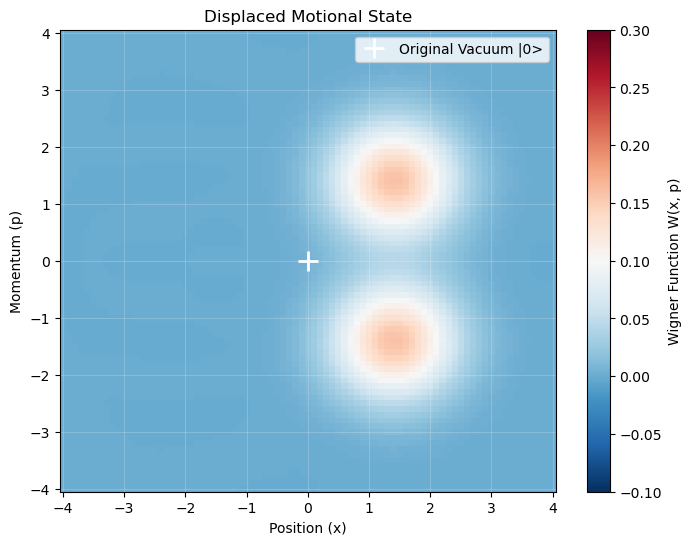

In [35]:
state =protocol(nothing, 1.0 , 1.0)

plot_wigner(state)

In [36]:
using LinearAlgebra

In [37]:
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end


calculate_qcrb (generic function with 1 method)

Simulating Fock State |0⟩ (Ancilla Readout)...
Beta: 0.01 μs, Fock |0⟩, QCRB: 631.0577211788228
Beta: 0.06 μs, Fock |0⟩, QCRB: 17.846365567871743
Beta: 0.11 μs, Fock |0⟩, QCRB: 5.479936388870943
Beta: 0.16 μs, Fock |0⟩, QCRB: 2.7347261800199143
Beta: 0.21 μs, Fock |0⟩, QCRB: 1.7062531326111054
Beta: 0.26 μs, Fock |0⟩, QCRB: 1.2216890817078796
Beta: 0.31 μs, Fock |0⟩, QCRB: 0.961672588226864
Beta: 0.36 μs, Fock |0⟩, QCRB: 0.8138157702973869
Beta: 0.41 μs, Fock |0⟩, QCRB: 0.7305763327467335
Beta: 0.46 μs, Fock |0⟩, QCRB: 0.6890110867878403
Beta: 0.51 μs, Fock |0⟩, QCRB: 0.6788373893170108
Beta: 0.56 μs, Fock |0⟩, QCRB: 0.6954850997305314
Beta: 0.61 μs, Fock |0⟩, QCRB: 0.7384503845036089
Beta: 0.66 μs, Fock |0⟩, QCRB: 0.8104881489435604
Beta: 0.71 μs, Fock |0⟩, QCRB: 0.9181786430754929
Beta: 0.76 μs, Fock |0⟩, QCRB: 1.0709543101803107
Beta: 0.81 μs, Fock |0⟩, QCRB: 1.2863050120649326
Beta: 0.86 μs, Fock |0⟩, QCRB: 1.587007145116539
Beta: 0.91 μs, Fock |0⟩, QCRB: 2.0118207233123426
Beta: 0

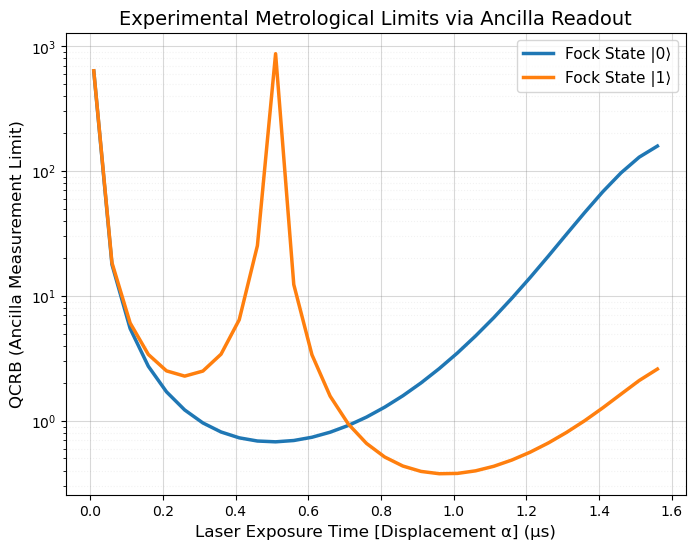

In [38]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Fock State |0⟩ (Ancilla Readout)...
Beta: 0.01 μs, Fock |0⟩, QCRB: 0.0013836056528358596
Beta: 0.06 μs, Fock |0⟩, QCRB: 0.019372572171925735
Beta: 0.11 μs, Fock |0⟩, QCRB: 0.032332575640934835
Beta: 0.16 μs, Fock |0⟩, QCRB: 0.04049764149075644
Beta: 0.21 μs, Fock |0⟩, QCRB: 0.048494385537537266
Beta: 0.26 μs, Fock |0⟩, QCRB: 0.05609067945503735
Beta: 0.31 μs, Fock |0⟩, QCRB: 0.06499922708854616
Beta: 0.36 μs, Fock |0⟩, QCRB: 0.07658932484703229
Beta: 0.41 μs, Fock |0⟩, QCRB: 0.08927743353958142
Beta: 0.46 μs, Fock |0⟩, QCRB: 0.10808731297339512
Beta: 0.51 μs, Fock |0⟩, QCRB: 0.12965223423889974
Beta: 0.56 μs, Fock |0⟩, QCRB: 0.15998440274345452
Beta: 0.61 μs, Fock |0⟩, QCRB: 0.1997999189923541
Beta: 0.66 μs, Fock |0⟩, QCRB: 0.2513684625436154
Beta: 0.71 μs, Fock |0⟩, QCRB: 0.3260247493098007
Beta: 0.76 μs, Fock |0⟩, QCRB: 0.4220754065082817
Beta: 0.81 μs, Fock |0⟩, QCRB: 0.5644405471151345
Beta: 0.86 μs, Fock |0⟩, QCRB: 0.7599225121045337
Beta: 0.91 μs, Fock |0⟩, QCRB: 1.041

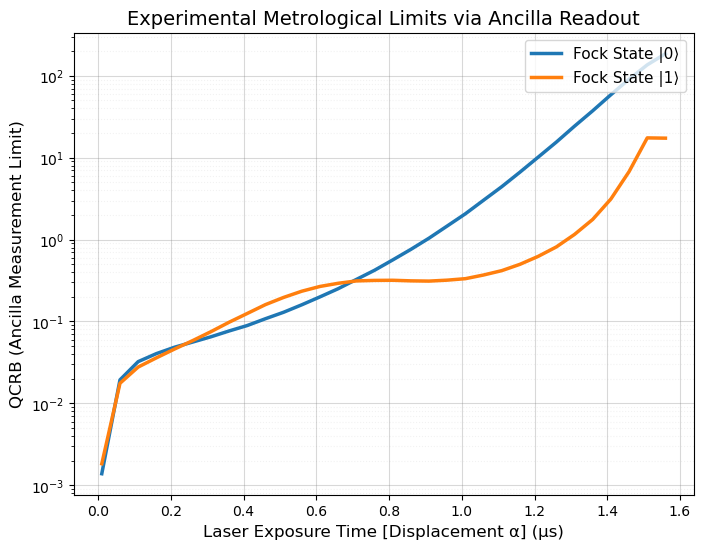

In [39]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 0.05

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial, 1, t+d_alpha)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

In [40]:
println(fockstate(mode, 0))

Ket(dim=11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im


In [41]:
ψ_ion = normalize(ion["g"] - ion["e"])
ψ_mode = fockstate(mode, 1)
ψ_initial = ψ_ion ⊗ ψ_mode

println(ψ_initial)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
                 0.0 + 0.0im
                -0.0 + 0.0im
  0.7071067811865475 + 0.0im
 -0.7071067811865475 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im


Simulating Fock State |0⟩ (Ancilla Readout)...
Beta: 0.01 μs, Fock |0⟩, QCRB: 0.056167647878133185
Beta: 0.06 μs, Fock |0⟩, QCRB: 3.2912474922798554
Beta: 0.11 μs, Fock |0⟩, QCRB: 2.0786584592937016
Beta: 0.16 μs, Fock |0⟩, QCRB: 1.659289516975437
Beta: 0.21 μs, Fock |0⟩, QCRB: 1.5842157520633808
Beta: 0.26 μs, Fock |0⟩, QCRB: 1.6844442135679718
Beta: 0.31 μs, Fock |0⟩, QCRB: 1.9320037283307978
Beta: 0.36 μs, Fock |0⟩, QCRB: 2.342610700832501
Beta: 0.41 μs, Fock |0⟩, QCRB: 2.9491086246886278
Beta: 0.46 μs, Fock |0⟩, QCRB: 3.7986587450199445
Beta: 0.51 μs, Fock |0⟩, QCRB: 4.922257666922885
Beta: 0.56 μs, Fock |0⟩, QCRB: 6.3548713143087125
Beta: 0.61 μs, Fock |0⟩, QCRB: 8.110295512743974
Beta: 0.66 μs, Fock |0⟩, QCRB: 10.22441246250294
Beta: 0.71 μs, Fock |0⟩, QCRB: 12.794436478618206
Beta: 0.76 μs, Fock |0⟩, QCRB: 15.989237916298215
Beta: 0.81 μs, Fock |0⟩, QCRB: 20.180570286599963
Beta: 0.86 μs, Fock |0⟩, QCRB: 25.968457390472302
Beta: 0.91 μs, Fock |0⟩, QCRB: 34.43460570796624
Beta: 0

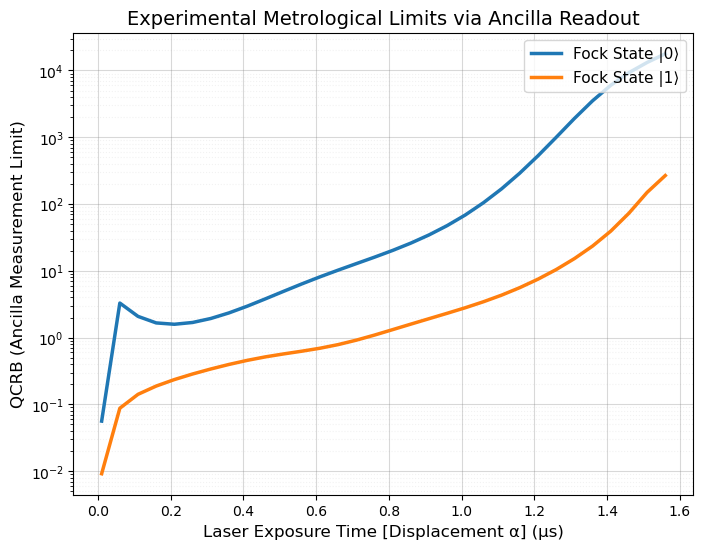

In [42]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 0.05

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = SDF_apply_with_alpha(pi/2, 0.05, true, nothing, n)
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

In [43]:
state = SDF_apply_with_alpha(pi/2, 0.05, true, nothing, 0)


Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.7062116924118327 - 0.00429483943087498im
  -0.7062116924118327 + 0.00429483943087498im
 -0.00020407041879774 - 0.0352886891393743im
 -0.00020407041879774 - 0.0352886891393743im
  0.00124527763385502 - 1.316633128369e-5im
 -0.00124527763385502 + 1.316633128369e-5im
     -3.6666164102e-7 - 3.58371286846e-5im
     -3.6666164102e-7 - 3.58371286846e-5im
      8.9199911937e-7 - 1.343640359e-8im
     -8.9199911937e-7 + 1.343640359e-8im
                      ⋮
       -4.0209951e-10 + 7.86208e-12im
          -1.4419e-13 - 7.53814e-12im
          -1.4419e-13 - 7.53814e-12im
           1.3201e-13 - 3.17e-15im
          -1.3201e-13 + 3.17e-15im
             -5.0e-17 - 2.18e-15im
             -5.0e-17 - 2.18e-15im
              3.0e-17 - 0.0im
             -3.0e-17 + 0.0im

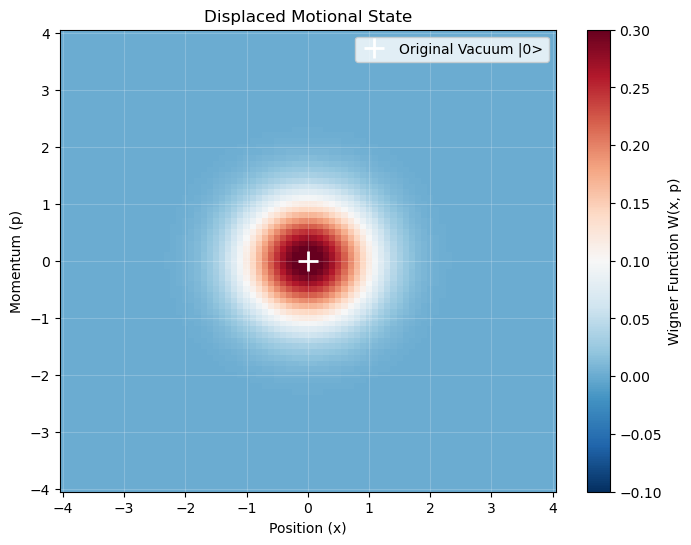

In [44]:
plot_wigner(state)

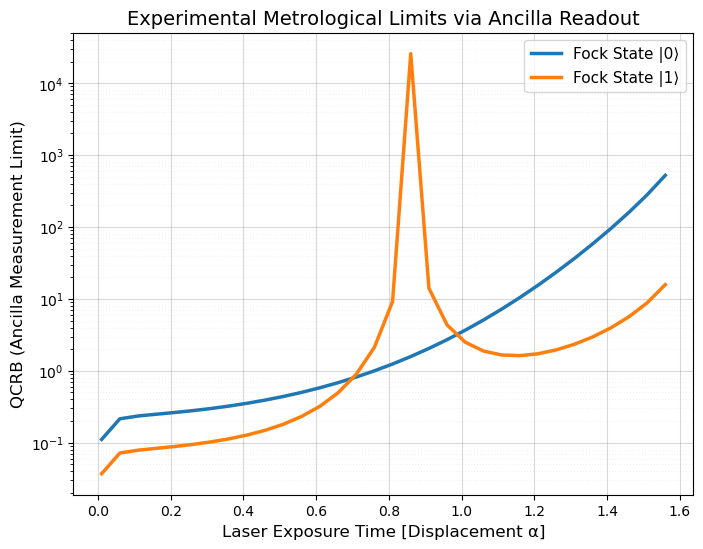

Simulating Fock State |0⟩ (Ancilla Readout)...
Alpha: 0.01 | Fock |0⟩ | QCRB: 0.1112000329703575
Alpha: 0.06 | Fock |0⟩ | QCRB: 0.2151173254740836
Alpha: 0.11 | Fock |0⟩ | QCRB: 0.23543932434080875
Alpha: 0.16 | Fock |0⟩ | QCRB: 0.24917384835869438
Alpha: 0.21 | Fock |0⟩ | QCRB: 0.26308836482525666
Alpha: 0.26 | Fock |0⟩ | QCRB: 0.27927579809001934
Alpha: 0.31 | Fock |0⟩ | QCRB: 0.2989858501423545
Alpha: 0.36 | Fock |0⟩ | QCRB: 0.3233802838903287
Alpha: 0.41 | Fock |0⟩ | QCRB: 0.35381110469518995
Alpha: 0.46 | Fock |0⟩ | QCRB: 0.3920085931908656
Alpha: 0.51 | Fock |0⟩ | QCRB: 0.44028162088315526
Alpha: 0.56 | Fock |0⟩ | QCRB: 0.5017815750983347
Alpha: 0.61 | Fock |0⟩ | QCRB: 0.5808792755277886
Alpha: 0.66 | Fock |0⟩ | QCRB: 0.683721981437727
Alpha: 0.71 | Fock |0⟩ | QCRB: 0.8190729334998448
Alpha: 0.76 | Fock |0⟩ | QCRB: 0.9995962829110359
Alpha: 0.81 | Fock |0⟩ | QCRB: 1.2438515938744437
Alpha: 0.86 | Fock |0⟩ | QCRB: 1.579433039560234
Alpha: 0.91 | Fock |0⟩ | QCRB: 2.047980028314024


In [45]:
# ---------------------------------------------------------
# Analytical QCRB Simulation Loop (State-Dependent Signal)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 

# Initialize the ion's spin state to the |g⟩ - |e⟩ superposition
ψ_ion = normalize(ion["g"] - ion["e"])

# Infinitesimal mathematical signal magnitude
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# 1. Define the Spin Projectors once outside the loop
P_g = projector(ion["g"])
P_e = projector(ion["e"])
sim_mode = zmodes(trap)[1]

# 2. Define a helper function to generate instantaneous SDF matrices
function analytic_SDF(alpha_val, mode, Pg, Pe)
    D_pos = displace(mode, alpha_val)
    D_neg = displace(mode, -alpha_val)
    
    # |g⟩⟨g| ⊗ D(α) + |e⟩⟨e| ⊗ D(-α)
    return (Pg ⊗ D_pos) + (Pe ⊗ D_neg)
end

# 3. Pre-build the State-Dependent Perturbation Signal
# This creates a tiny cat state displacement instead of a global kick
D_signal_SDF = analytic_SDF(d_alpha, sim_mode, P_g, P_e)


for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: The initial state is perturbed via a state-dependent kick
    ψ_initial_perturbed = D_signal_SDF * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 4. Generate the instantaneous large cat state matrix for this time step
        U_cat = analytic_SDF(t, sim_mode, P_g, P_e)
        
        # 1. Base Trajectory (Instant Matrix Multiplication)
        sol1 = U_cat * ψ_initial
        ancilla_base = ptrace(sol1, 2) 
        
        # 2. Perturbed Trajectory (Instant Matrix Multiplication)
        sol2 = U_cat * ψ_initial_perturbed
        ancilla_perturbed = ptrace(sol2, 2)

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Alpha: ", round(t, digits=2), " | Fock |", n, "⟩ | QCRB: ", qcrb)
    end

    # Plot the line for this specific Fock state
    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits if needed

PyPlot.xlabel("Laser Exposure Time [Displacement α]", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)

PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

In [46]:
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

print(D_signal)

Operator(dim=11x11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
     0.99995+0.0im                   0.0+0.0099995im     -7.07071e-5+0.0im                   0.0-4.08228e-7im     2.04114e-9+0.0im                   0.0+9.12825e-12im    -3.727e-14+0.0im                   0.0-1.4e-16im               0.0+0.0im                   0.0+0.0im                  -0.0+0.0im
         0.0+0.0099995im         0.99985+0.0im                   0.0+0.0141407im    -0.000122464+0.0im                   0.0-8.16435e-7im     4.56404e-9+0.0im                   0.0+2.23592e-11im    -9.859e-14+0.0im                   0.0-4.0e-16im               0.0+0.0im                   0.0+0.0im
 -7.07071e-5+0.0im                   0.0+0.0141407im         0.99975+0.0im                   0.0+0.0173179im    -0.000173185+0.0im                   0.0-1.29087e-6im     7.90498e-9+0.0im                   0.0+4.18295e-11im   -1.9719e-13+0.0im                   0.0-8.5e-16im               0.0+0.0im
         0.0-4.08228e-7im   -0.000

In [51]:
state = SDF_apply_with_alpha(0, 1, false, nothing, 0)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.43111289877874337 + 2.18469380732e-6im
   -0.427647362589656 - 2.55453038901e-6im
   -1.615101999793e-5 + 0.4308800578530104im
    1.679435547909e-5 - 0.427425679276664im
  -0.3041374776794986 - 2.17331456665e-5im
   0.3017057515457723 + 2.237575940737e-5im
    1.873019819735e-5 - 0.17506613369128643im
   -1.920585875263e-5 + 0.17366908644718534im
  0.08716156874251516 + 1.255787839034e-5im
 -0.08646841784177287 - 1.284602577211e-5im
                      ⋮
  0.01559597059500932 + 3.57390891353e-6im
     1.56007037403e-6 - 0.00589441439541435im
    -1.58943535426e-6 + 0.00584780982783528im
    0.002066031203257 + 6.3535271978e-7im
   -0.002049778210635 - 6.4672081425e-7im
     -2.4315547894e-7 + 0.00067630531748294im
      2.4729655469e-7 - 0.00067098301050064im
 -0.00023135077354807 - 7.304532648e-8im
  0.00022951575316618 + 7.434514395e-8im

Simulating Fock State |0⟩ (Ancilla Readout)...


sys:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


Beta: 0.01 μs, Fock |0⟩, QCRB: 631.0577211788228
Beta: 0.06 μs, Fock |0⟩, QCRB: 17.846365567871743
Beta: 0.11 μs, Fock |0⟩, QCRB: 5.479936388870943
Beta: 0.16 μs, Fock |0⟩, QCRB: 2.7347261800199143
Beta: 0.21 μs, Fock |0⟩, QCRB: 1.7062531326111054
Beta: 0.26 μs, Fock |0⟩, QCRB: 1.2216890817078796
Beta: 0.31 μs, Fock |0⟩, QCRB: 0.961672588226864
Beta: 0.36 μs, Fock |0⟩, QCRB: 0.8138157702973869
Beta: 0.41 μs, Fock |0⟩, QCRB: 0.7305763327467335
Beta: 0.46 μs, Fock |0⟩, QCRB: 0.6890110867878403
Beta: 0.51 μs, Fock |0⟩, QCRB: 0.6788373893170108
Beta: 0.56 μs, Fock |0⟩, QCRB: 0.6954850997305314
Beta: 0.61 μs, Fock |0⟩, QCRB: 0.7384503845036089
Beta: 0.66 μs, Fock |0⟩, QCRB: 0.8104881489435604
Beta: 0.71 μs, Fock |0⟩, QCRB: 0.9181786430754929
Beta: 0.76 μs, Fock |0⟩, QCRB: 1.0709543101803107
Beta: 0.81 μs, Fock |0⟩, QCRB: 1.2863050120649326
Beta: 0.86 μs, Fock |0⟩, QCRB: 1.587007145116539
Beta: 0.91 μs, Fock |0⟩, QCRB: 2.0118207233123426
Beta: 0.96 μs, Fock |0⟩, QCRB: 2.618523622011795
Beta:

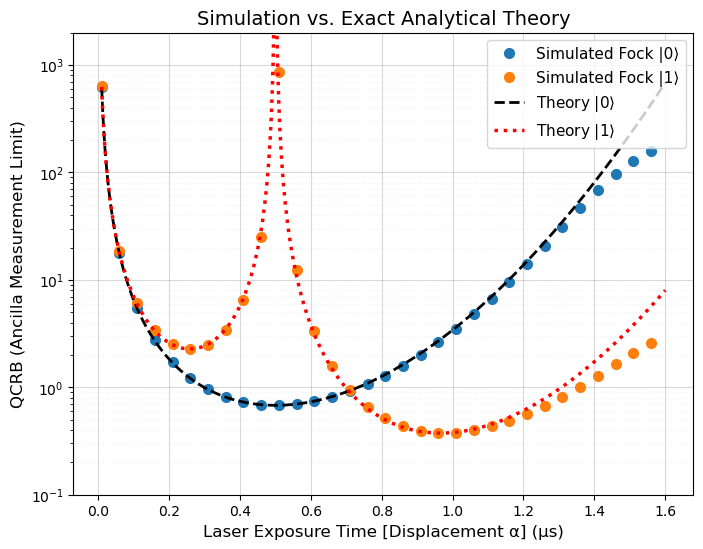

In [53]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])

# Infinitesimal mathematical signal
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    # Use dots ("o") for the simulation so the theory line can pass through them
    color_choice = n == 0 ? "tab:blue" : "tab:orange"
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_choice, markersize=7, label="Simulated Fock |$n⟩")
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# Use a high-resolution X-axis to capture the smooth curves and the exact tip of the spike
alphas_theory = range(0.01, stop=t_max, length=1000)

# Theory for |0⟩ (L_0 = 1)
# Formula: exp(4x^2) / (4x^2)
qcrb_theory_0 = @. exp(4 * alphas_theory^2) / (16 * alphas_theory^2 + 1e-15)

# Theory for |1⟩ (L_1 = 1 - 4x^2)
# Formula: exp(4x^2) / (4x^2 * (1 - 4x^2)^2)
qcrb_theory_1 = @. exp(4 * alphas_theory^2) / (16 * alphas_theory^2 * (1 - 4 * alphas_theory^2)^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0, "--", color="black", linewidth=2, label=L"Theory $|0\rangle$")
PyPlot.plot(alphas_theory, qcrb_theory_1, ":", color="red", linewidth=2.5, label=L"Theory $|1\rangle$")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs. Exact Analytical Theory", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Fock State |2⟩ (Ancilla Readout)...
Beta: 0.01 μs, Fock |2⟩, QCRB: 644.6033600657032
Beta: 0.06 μs, Fock |2⟩, QCRB: 19.188900940400433
Beta: 0.11 μs, Fock |2⟩, QCRB: 6.758004639894445
Beta: 0.16 μs, Fock |2⟩, QCRB: 4.263513434013243
Beta: 0.21 μs, Fock |2⟩, QCRB: 3.8232081347957934
Beta: 0.26 μs, Fock |2⟩, QCRB: 4.770194674782538
Beta: 0.31 μs, Fock |2⟩, QCRB: 9.440990634601729
Beta: 0.36 μs, Fock |2⟩, QCRB: 63.34775033546036
Beta: 0.41 μs, Fock |2⟩, QCRB: 68.37942076938877
Beta: 0.46 μs, Fock |2⟩, QCRB: 6.584801165863057
Beta: 0.51 μs, Fock |2⟩, QCRB: 2.373753871915951
Beta: 0.56 μs, Fock |2⟩, QCRB: 1.3168167909196056
Beta: 0.61 μs, Fock |2⟩, QCRB: 0.944379579988466
Beta: 0.66 μs, Fock |2⟩, QCRB: 0.8241697515427188
Beta: 0.71 μs, Fock |2⟩, QCRB: 0.8635278921495099
Beta: 0.76 μs, Fock |2⟩, QCRB: 1.1088822468118762
Beta: 0.81 μs, Fock |2⟩, QCRB: 1.8923483416491513
Beta: 0.86 μs, Fock |2⟩, QCRB: 5.533843069147909
Beta: 0.91 μs, Fock |2⟩, QCRB: 136.64836582581816
Beta: 0.96 μs,

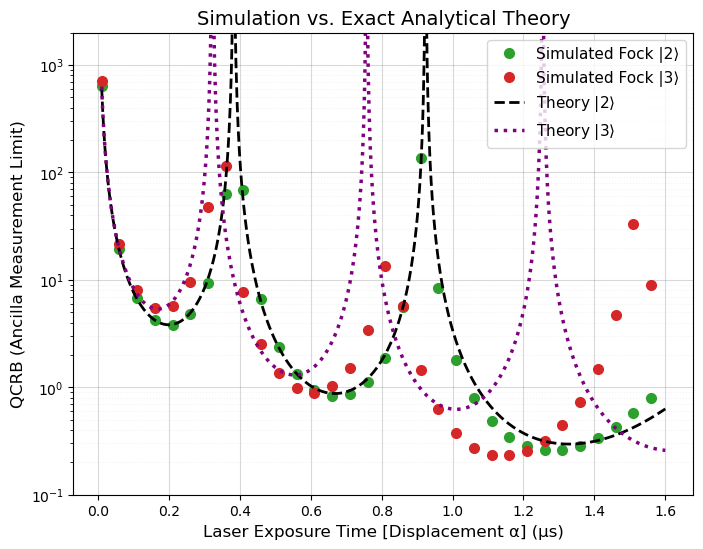

In [55]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 2:3 
ψ_ion = normalize(ion["g"] - ion["e"])

# Infinitesimal mathematical signal
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    # Use dots ("o") for the simulation so the theory line can pass through them
    color_choice = n == 2 ? "tab:green" : "tab:red"
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_choice, markersize=7, label="Simulated Fock |$n⟩")
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# Use a high-resolution X-axis to capture the smooth curves and the exact tip of the spike
alphas_theory = range(0.01, stop=t_max, length=1000)

# Calculate x = 4a^2 to make the Laguerre polynomials readable
x_th = @. 4 * alphas_theory^2

# Theory for |2⟩ (L_2 = 0.5 * (x^2 - 4x + 2))
L2 = @. 0.5 * (x_th^2 - 4 * x_th + 2)
# Formula: exp(4x^2) / (16x^2 * (L_2)^2)
qcrb_theory_2 = @. exp(x_th) / (16 * alphas_theory^2 * L2^2 + 1e-15)

# Theory for |3⟩ (L_3 = (1/6) * (-x^3 + 9x^2 - 18x + 6))
L3 = @. (1/6) * (-x_th^3 + 9 * x_th^2 - 18 * x_th + 6)
# Formula: exp(4x^2) / (16x^2 * (L_3)^2)
qcrb_theory_3 = @. exp(x_th) / (16 * alphas_theory^2 * L3^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_2, "--", color="black", linewidth=2, label=L"Theory $|2\rangle$")
PyPlot.plot(alphas_theory, qcrb_theory_3, ":", color="purple", linewidth=2.5, label=L"Theory $|3\rangle$")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs. Exact Analytical Theory", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)